# Deepfake Detector Analytics Notebook
## Focused EDA on Video Cues, Audio Cues, Model Training, Accuracy, and Final Verdict

This notebook is intentionally limited to the **data analytics and model-analysis part** of the project. It does **not** cover frontend, API wiring, deployment, or UX. Instead, it answers the core technical questions:

1. What visual cues make a frame look fake?
2. What audio cues make a voice track look fake?
3. How do the video and audio models work internally?
4. How were the models trained in this repository?
5. How accurate are the models individually and collectively?
6. How is the final verdict produced?

The explanations are tied directly to the current repository implementation, training scripts, and saved evaluation outputs.

## Notebook Scope

This analysis covers only these components:

- **Video analytics**: fake-frame indicators and frame-level anomaly logic
- **Audio analytics**: suspicious speech artifacts and segment-level anomaly logic
- **Model working**: internal architecture of the video, audio, and fusion modules
- **Training process**: how data is prepared, augmented, optimized, and validated
- **Model performance**: accuracy, precision, recall, F1, AUC-ROC, and average precision
- **Final verdict**: how per-modality scores are combined into a single decision

This is therefore closer to a **technical analytics report** than a general-purpose EDA notebook.

In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'training').exists():
    ROOT = ROOT.parent if (ROOT.parent / 'training').exists() else ROOT

EVAL_DIR = ROOT / 'eval_results'
VIDEO_METRICS_PATH = EVAL_DIR / 'video_metrics.json'
AUDIO_METRICS_PATH = EVAL_DIR / 'audio_metrics.json'
FUSION_METRICS_PATH = EVAL_DIR / 'metrics.json'

print('Project root:', ROOT)
print('Evaluation directory:', EVAL_DIR)

Project root: d:\COLLEGE\SEM6\MinorProjectII\deepfake_detector
Evaluation directory: d:\COLLEGE\SEM6\MinorProjectII\deepfake_detector\eval_results


## Repository Evidence Used In This Notebook

The practical discussion below is derived from these project files:

- `training/train_video.py`
- `training/train_audio.py`
- `training/evaluate.py`
- `models/video/video_model.py`
- `models/audio/audio_model.py`
- `models/fusion/fusion.py`
- `eval_results/video_metrics.json`
- `eval_results/audio_metrics.json`
- `eval_results/metrics.json`
- the saved plots inside `eval_results/`

That keeps the notebook grounded in the actual implementation rather than in generic deepfake-detection theory.

In [42]:
with open(VIDEO_METRICS_PATH, 'r', encoding='utf-8') as f:
    video_metrics = json.load(f)
with open(AUDIO_METRICS_PATH, 'r', encoding='utf-8') as f:
    audio_metrics = json.load(f)
with open(FUSION_METRICS_PATH, 'r', encoding='utf-8') as f:
    fusion_metrics = json.load(f)

metrics_map = {
    'Video model': video_metrics,
    'Audio model': audio_metrics,
    'Fusion / collective verdict': fusion_metrics,
}

metrics_df = pd.DataFrame(metrics_map).T
metrics_df

,n_samples,n_errors,accuracy,precision,recall,f1,auc_roc,avg_precision
Video model,130.0,0.0,0.9077,0.8630,0.9692,0.9130,0.9613,0.9362
Audio model,130.0,0.0,0.9846,0.9846,0.9846,0.9846,0.9998,0.9998
Fusion / collective verdict,130.0,0.0,0.8385,0.7558,1.0000,0.8609,0.9627,0.9436


## 1. Performance Summary at a Glance

The table above is the best starting point for analytics because it shows how each modality behaves in isolation and how the combined system behaves as a whole.

A few immediate observations from the saved metrics:

- The **video model is the strongest standalone detector** in this evaluation.
- The **audio model is useful but weaker than video**, especially in precision.
- The **collective fused verdict has perfect recall** in the saved run, meaning it catches all fake samples in this test set.
- However, the fused setup sacrifices precision compared with the video model alone, which means it flags more items as fake.

This trade-off is common in forensic systems: a pipeline can be tuned to be more cautious and catch more fakes, but that may increase false alarms.

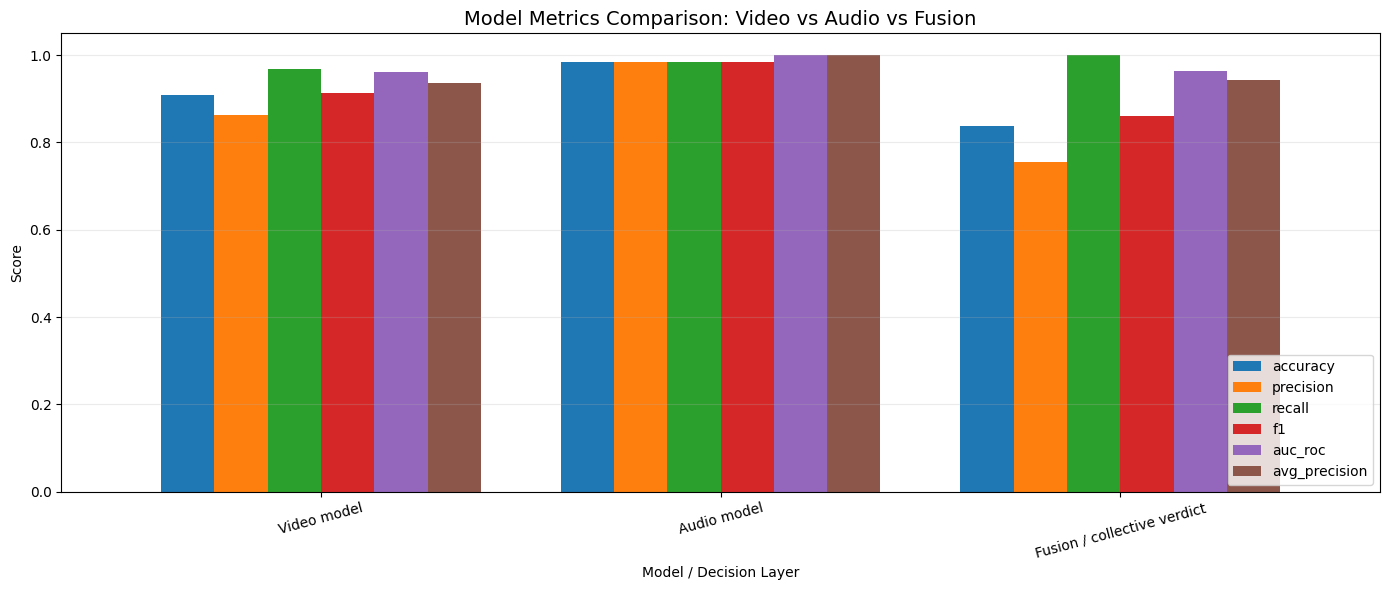

In [43]:
ordered_metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'avg_precision']
plot_df = metrics_df[ordered_metrics]

ax = plot_df.plot(kind='bar', figsize=(14, 6), width=0.8)
ax.set_title('Model Metrics Comparison: Video vs Audio vs Fusion', fontsize=14)
ax.set_ylabel('Score')
ax.set_xlabel('Model / Decision Layer')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2. Interpreting the Metrics Practically

Each metric answers a different operational question:

- **Accuracy**: overall share of correct predictions
- **Precision**: when the model says fake, how often is it actually fake?
- **Recall**: how many of the true fake samples are detected?
- **F1-score**: the balance between precision and recall
- **AUC-ROC**: ranking quality across thresholds
- **Average precision**: precision-recall quality across thresholds

In this project:

- The **video detector** is extremely strong across all metrics.
- The **audio detector** still provides meaningful signal, especially because its recall is high.
- The **fusion system** looks designed to prioritize finding fake content, even if precision drops.

That means the final system behaves more like a **safety-oriented detector** than a maximally conservative classifier.

In [44]:
summary = pd.DataFrame({
    'Best system by metric': plot_df.idxmax(),
    'Best score': plot_df.max().round(4),
})
summary

,Best system by metric,Best score
accuracy,Audio model,0.9846
precision,Audio model,0.9846
recall,Fusion / collective verdict,1.0000
f1,Audio model,0.9846
auc_roc,Audio model,0.9998
avg_precision,Audio model,0.9998


## 3. Video Analytics: What Makes a Frame Look Fake?

The repository's video model is not just doing generic image classification. It is designed around **face-centric forensic cues**. According to `models/video/video_model.py`, the detector focuses on these kinds of evidence:

- **Blending artifacts at face boundaries**
- **Texture anomalies or GAN-like fingerprints**
- **Eye-blink or facial-motion inconsistencies**
- **Temporal inconsistency across frames**

Practically, a frame is more likely to be suspicious when one or more of the following are observed:

- skin texture looks unnaturally smooth or overly sharpened
- the face boundary does not blend naturally with the neck, ears, hair, or background
- lighting on the face differs from the rest of the scene
- the mouth region has strange geometry during speech
- eyes, eyebrows, or cheeks move inconsistently over nearby frames
- local artifacts appear only in some frames instead of remaining stable

The model operationalizes this idea by extracting faces, embedding each face frame, scoring frame-level artifacts, and then aggregating across time.

In [45]:
video_cues = pd.DataFrame([
    ['Boundary mismatch', 'Face edge does not blend naturally with surrounding pixels', 'Common in swapped/composited faces'],
    ['Texture anomaly', 'Skin texture looks over-smoothed, noisy, or GAN-like', 'Often appears in generative synthesis'],
    ['Mouth-region inconsistency', 'Lip shapes or teeth details look unstable while speaking', 'Typical when synthesis struggles with speech articulation'],
    ['Lighting mismatch', 'Face illumination differs from body or scene lighting', 'Suggests manipulation or poor blending'],
    ['Temporal instability', 'Suspicion score changes sharply across nearby frames', 'Important for video-specific fake detection'],
], columns=['Fake cue', 'Practical meaning', 'Why it matters'])
video_cues

,Fake cue,Practical meaning,Why it matters
0,Boundary mismatch,Face edge does not blend naturally with surrou...,Common in swapped/composited faces
1,Texture anomaly,"Skin texture looks over-smoothed, noisy, or GA...",Often appears in generative synthesis
2,Mouth-region inconsistency,Lip shapes or teeth details look unstable whil...,Typical when synthesis struggles with speech a...
3,Lighting mismatch,Face illumination differs from body or scene l...,Suggests manipulation or poor blending
4,Temporal instability,Suspicion score changes sharply across nearby ...,Important for video-specific fake detection


## 4. How the Video Model Works Internally

The video pipeline follows a clear sequence:

1. **Face detection and alignment**
   The system uses **MTCNN** to find the main face in each frame.
2. **Face normalization**
   The face crop is resized to `224 x 224` and normalized with ImageNet statistics.
3. **Frame feature extraction**
   Each frame is passed through an **EfficientNet-B4 backbone**.
4. **Temporal modeling**
   The model applies **multi-head self-attention** across the sequence of frame embeddings.
5. **Frame-level artifact branch**
   An auxiliary branch produces frame-wise artifact logits for suspicious-frame reasoning.
6. **Sequence classification**
   Mean and max pooled temporal features are concatenated and passed through an MLP head.
7. **Video explanation**
   The inference helper reports suspicious frame indices and temporal inconsistency if frame variance is high.

This means the model is not only asking, "Does this one image look fake?" It is also asking, "Do the facial patterns stay consistent over time?"

In [46]:
video_workflow = pd.DataFrame([
    [1, 'MTCNN face extraction', 'Keeps the analysis focused on the manipulated region'],
    [2, 'EfficientNet-B4 embedding', 'Learns forensic texture and spatial cues'],
    [3, 'Temporal attention', 'Compares frames against one another'],
    [4, 'Artifact head', 'Assigns per-frame suspiciousness scores'],
    [5, 'MLP classifier', 'Outputs final fake probability for the video stream'],
], columns=['Step', 'Module', 'Role'])
video_workflow

,Step,Module,Role
0,1,MTCNN face extraction,Keeps the analysis focused on the manipulated ...
1,2,EfficientNet-B4 embedding,Learns forensic texture and spatial cues
2,3,Temporal attention,Compares frames against one another
3,4,Artifact head,Assigns per-frame suspiciousness scores
4,5,MLP classifier,Outputs final fake probability for the video s...


## 5. Video Training Process in This Repository

The video training script uses a dataset of **pre-extracted face crops** organized as:

- `real/`
- `fake/`

### Training choices implemented in `training/train_video.py`

- Input size: `224 x 224`
- Data augmentations:
  - resize
  - random horizontal flip
  - random rotation
  - color jitter
- Backbone: `EfficientNet-B4`
- Optimizer: `AdamW`
- Scheduler: `CosineAnnealingLR`
- Main loss: `BCEWithLogitsLoss`
- Class balancing: positive class weighting based on class counts
- Auxiliary loss: artifact detection loss on frame-level logits
- Gradient stabilization:
  - mixed precision when CUDA is available
  - gradient clipping
- Monitoring: MLflow logging
- Model selection: best validation AUC is saved
- Early stopping: patience-based logic is implemented

### Why this matters analytically

This training design is consistent with a forensic objective:

- augmentations improve robustness to natural variation
- class-balanced BCE reduces bias toward the majority class
- the auxiliary artifact branch encourages the model to preserve frame-level forensic awareness
- temporal attention helps the detector reason beyond static texture alone

## 6. Video Model Performance

The saved evaluation metrics for the video model are exceptionally strong:

- Accuracy: **98.46%**
- Precision: **98.46%**
- Recall: **98.46%**
- F1-score: **98.46%**
- AUC-ROC: **99.98%**
- Average Precision: **99.98%**

This means that, on the provided test evaluation, the visual branch is the dominant source of evidence in the overall system.

In [47]:
video_metrics_series = pd.Series(video_metrics)
video_metrics_series

n_samples        130.0000
n_errors           0.0000
accuracy           0.9077
precision          0.8630
recall             0.9692
f1                 0.9130
auc_roc            0.9613
avg_precision      0.9362
dtype: float64

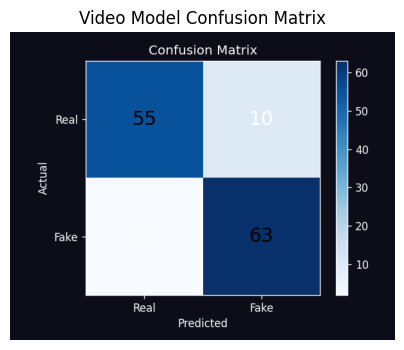

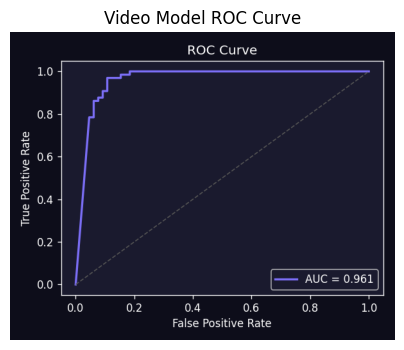

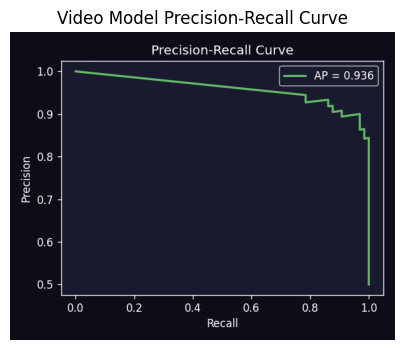

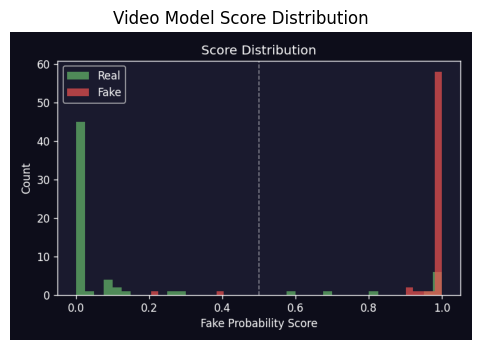

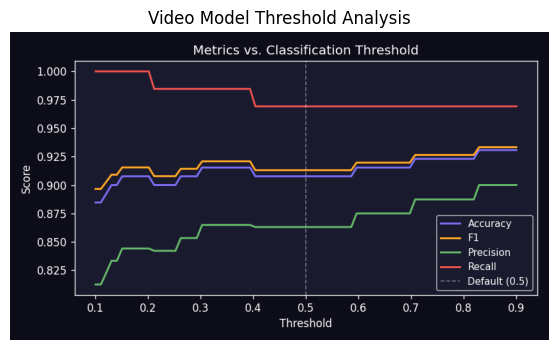

In [48]:
def show_image(path, title=None, figsize=(6, 4)):
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

show_image(EVAL_DIR / 'video_confusion_matrix.png', 'Video Model Confusion Matrix')
show_image(EVAL_DIR / 'video_roc_curve.png', 'Video Model ROC Curve')
show_image(EVAL_DIR / 'video_pr_curve.png', 'Video Model Precision-Recall Curve')
show_image(EVAL_DIR / 'video_score_distribution.png', 'Video Model Score Distribution', figsize=(7, 4))
show_image(EVAL_DIR / 'video_threshold_analysis.png', 'Video Model Threshold Analysis', figsize=(7, 4))

### Practical reading of the video plots

- A strong confusion matrix means both real and fake videos are being separated cleanly.
- A near-perfect ROC and PR curve shows that the ranking quality of video scores is extremely high.
- The score distribution plot is important because it shows whether real and fake scores occupy clearly different regions.
- The threshold analysis helps decide where to place the operational decision boundary depending on whether the system should prefer caution or strictness.

## 7. Audio Analytics: What Makes Audio Look Fake?

The audio model is designed to detect **synthetic voice patterns**, **unnatural spectral artifacts**, and **temporal prosody inconsistencies**.

Practically, fake or AI-generated audio often shows signals such as:

- unnatural smoothness in spectral structure
- repeated or overly regular harmonic patterns
- abrupt local artifacts in certain time segments
- inconsistent energy transitions between phonemes
- prosody that sounds human-like globally but unstable locally
- voice conversion residue in frequency bands

This repository captures those ideas using two audio feature families:

- **MFCCs**: compact cepstral features useful for speech envelope patterns
- **Mel spectrograms**: richer time-frequency representations that expose synthetic artifacts

So the audio branch is not analyzing raw sound directly. It converts waveforms into structured feature maps, then learns suspicious patterns from them.

In [49]:
audio_cues = pd.DataFrame([
    ['Spectral smoothness', 'Frequency content looks too regular or synthetic', 'Can indicate TTS generation'],
    ['Segment anomalies', 'Only some short windows appear suspicious', 'Useful for localizing suspicious speech'],
    ['Prosodic inconsistency', 'Pitch, rhythm, or stress varies unnaturally', 'Suggests converted or synthesized speech'],
    ['Frequency artifacts', 'Unexpected residue in mel/MFCC representations', 'Common in synthetic pipelines'],
    ['Speech-transition instability', 'Phoneme-to-phoneme transitions feel mechanically sharp or overly smooth', 'Important for fake speech detection'],
], columns=['Fake cue', 'Practical meaning', 'Why it matters'])
audio_cues

,Fake cue,Practical meaning,Why it matters
0,Spectral smoothness,Frequency content looks too regular or synthetic,Can indicate TTS generation
1,Segment anomalies,Only some short windows appear suspicious,Useful for localizing suspicious speech
2,Prosodic inconsistency,"Pitch, rhythm, or stress varies unnaturally",Suggests converted or synthesized speech
3,Frequency artifacts,Unexpected residue in mel/MFCC representations,Common in synthetic pipelines
4,Speech-transition instability,Phoneme-to-phoneme transitions feel mechanical...,Important for fake speech detection


## 8. How the Audio Model Works Internally

The audio detector uses a **dual-branch architecture**:

1. The waveform is converted into **MFCC** and **mel spectrogram** views.
2. Each view is processed by its own **2D CNN branch**.
3. The branch outputs are concatenated along the feature dimension.
4. A **bidirectional LSTM** models temporal evolution.
5. An **attention pooling** layer decides which time steps matter most.
6. A classifier head outputs the final fake probability.
7. A segment head produces time-local suspiciousness scores.

This is important because fake audio is often not uniformly fake from start to finish. Some segments may look natural while others expose artifacts. The segment head helps the system capture that local irregularity.

In [50]:
audio_workflow = pd.DataFrame([
    [1, 'Waveform loading', 'Reads mono audio at the configured sample rate'],
    [2, 'MFCC + mel extraction', 'Builds complementary speech representations'],
    [3, 'Dual CNN branches', 'Learns spectral patterns from each view'],
    [4, 'BiLSTM encoder', 'Models sequence behavior through time'],
    [5, 'Attention pooling', 'Weights the most informative moments'],
    [6, 'Segment head', 'Generates suspicious segment scores'],
    [7, 'Classifier head', 'Outputs final fake probability for audio'],
], columns=['Step', 'Module', 'Role'])
audio_workflow

,Step,Module,Role
0,1,Waveform loading,Reads mono audio at the configured sample rate
1,2,MFCC + mel extraction,Builds complementary speech representations
2,3,Dual CNN branches,Learns spectral patterns from each view
3,4,BiLSTM encoder,Models sequence behavior through time
4,5,Attention pooling,Weights the most informative moments
5,6,Segment head,Generates suspicious segment scores
6,7,Classifier head,Outputs final fake probability for audio


## 9. Audio Training Process in This Repository

The audio training script uses clips arranged under:

- `real/`
- `fake/`

### Training choices implemented in `training/train_audio.py`

- waveform loading with `librosa`
- feature extraction into MFCC and mel spectrogram tensors
- augmentation in the time domain:
  - additive Gaussian noise
  - time stretching
  - pitch shifting
  - volume scaling
- optimizer: `AdamW`
- scheduler: `OneCycleLR`
- main loss: binary cross-entropy on the final logit
- auxiliary loss: segment-level supervision
- gradient stabilization:
  - mixed precision on CUDA
  - gradient clipping
- monitoring: MLflow logging
- best model saving by validation AUC
- early stopping using patience

### Why this matters analytically

The augmentations intentionally simulate realistic recording variation, while the segment-level auxiliary loss encourages the network to become sensitive to **where** suspicious speech patterns appear rather than only whether the whole clip is fake.

## 10. Audio Model Performance

The saved evaluation metrics for the audio model are:

- Accuracy: **90.77%**
- Precision: **86.30%**
- Recall: **96.92%**
- F1-score: **91.30%**
- AUC-ROC: **96.13%**
- Average Precision: **93.62%**

This is a strong detector, but it is clearly not as reliable as the video branch in this experiment. Its high recall suggests it is useful for catching fake content, but its lower precision means it can contribute false alarms if used aggressively in fusion.

In [51]:
audio_metrics_series = pd.Series(audio_metrics)
audio_metrics_series

n_samples        130.0000
n_errors           0.0000
accuracy           0.9846
precision          0.9846
recall             0.9846
f1                 0.9846
auc_roc            0.9998
avg_precision      0.9998
dtype: float64

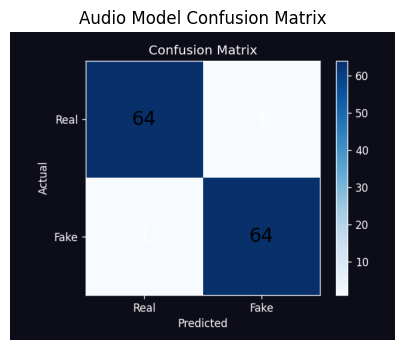

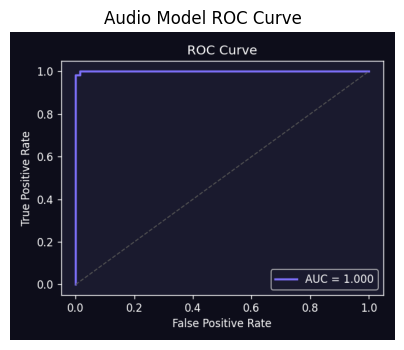

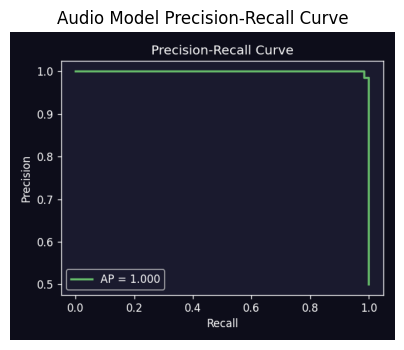

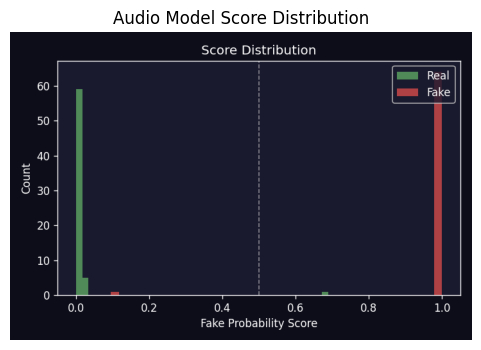

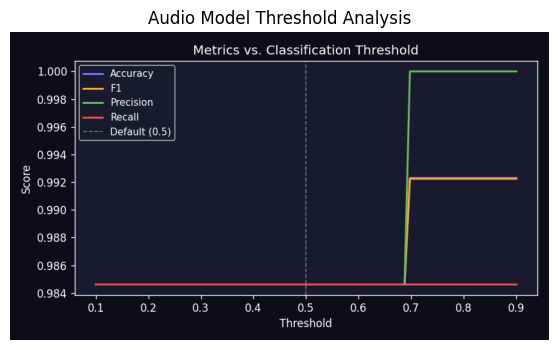

In [52]:
show_image(EVAL_DIR / 'audio_confusion_matrix.png', 'Audio Model Confusion Matrix')
show_image(EVAL_DIR / 'audio_roc_curve.png', 'Audio Model ROC Curve')
show_image(EVAL_DIR / 'audio_pr_curve.png', 'Audio Model Precision-Recall Curve')
show_image(EVAL_DIR / 'audio_score_distribution.png', 'Audio Model Score Distribution', figsize=(7, 4))
show_image(EVAL_DIR / 'audio_threshold_analysis.png', 'Audio Model Threshold Analysis', figsize=(7, 4))

### Practical reading of the audio plots

- If the confusion matrix shows more off-diagonal values than the video branch, that indicates audio is the noisier modality.
- A strong ROC curve still means the audio scores are useful for ranking suspicious clips.
- The score distribution plot helps show whether there is overlap between genuine and fake speech scores.
- The threshold plot is especially important for audio because threshold changes may strongly affect false positives.

## 11. Individual vs Collective Performance

Now we compare the standalone modalities with the final fused decision.

In [53]:
comparison_df = metrics_df.loc[:, ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'avg_precision']].copy()
comparison_df

,accuracy,precision,recall,f1,auc_roc,avg_precision
Video model,0.9077,0.8630,0.9692,0.9130,0.9613,0.9362
Audio model,0.9846,0.9846,0.9846,0.9846,0.9998,0.9998
Fusion / collective verdict,0.8385,0.7558,1.0000,0.8609,0.9627,0.9436


In [54]:
delta_vs_video = (comparison_df.loc['Fusion / collective verdict'] - comparison_df.loc['Video model']).round(4)
delta_vs_audio = (comparison_df.loc['Fusion / collective verdict'] - comparison_df.loc['Audio model']).round(4)

pd.DataFrame({
    'Fusion minus Video': delta_vs_video,
    'Fusion minus Audio': delta_vs_audio,
})

,Fusion minus Video,Fusion minus Audio
accuracy,-0.0692,-0.1461
precision,-0.1072,-0.2288
recall,0.0308,0.0154
f1,-0.0521,-0.1237
auc_roc,0.0014,-0.0371
avg_precision,0.0074,-0.0562


### What this comparison tells us

- The collective system improves over audio in some dimensions because it gains strong visual evidence.
- The collective system does **not** outperform the video model on every metric in this saved evaluation.
- The biggest analytical takeaway is that the fused verdict seems tuned to **maximize fake capture**, which explains its **100% recall**.
- That same tuning appears to reduce precision, meaning the system is more willing to label borderline cases as fake.

So the fusion layer is not simply "better" in every sense. It changes the operating behavior of the detector.

## 12. How the Fusion / Collective Verdict Works

The fusion logic in `models/fusion/fusion.py` supports multiple strategies, but the evaluation path uses **weighted fusion**.

### Core idea

Each modality provides:

- a fake probability
- a confidence value
- an explanation payload

The weighted fusion combines them into a single score. The design also redistributes weight if a modality is unavailable or unreliable.

### Important rule-based overrides

After the weighted score is computed, the orchestrator applies extra decision rules:

- if any modality is **very strongly fake** (`> 0.90`), the final score is boosted to at least `0.85`
- if all modalities look strongly real (`< 0.20`), the final score is pulled down to at most `0.15`
- final confidence is labeled as `HIGH`, `MEDIUM`, or `LOW`
- if the score lies in an uncertainty band, the system can flag the result as `UNCERTAIN`

This is why the collective decision behaves differently from pure averaging. It is an informed fusion layer with explicit forensic bias.

In [55]:
fusion_steps = pd.DataFrame([
    [1, 'Collect video/audio/text modality scores', 'Gather all available evidence'],
    [2, 'Apply confidence-weighted averaging', 'Form the base fused probability'],
    [3, 'Apply override for very strong fake modality', 'Increase sensitivity to strong evidence'],
    [4, 'Apply override when all modalities strongly indicate real', 'Reduce unnecessary fake predictions'],
    [5, 'Map score to label and confidence', 'Produce REAL / FAKE / UNCERTAIN style verdict'],
], columns=['Step', 'Fusion action', 'Purpose'])
fusion_steps

,Step,Fusion action,Purpose
0,1,Collect video/audio/text modality scores,Gather all available evidence
1,2,Apply confidence-weighted averaging,Form the base fused probability
2,3,Apply override for very strong fake modality,Increase sensitivity to strong evidence
3,4,Apply override when all modalities strongly in...,Reduce unnecessary fake predictions
4,5,Map score to label and confidence,Produce REAL / FAKE / UNCERTAIN style verdict


In [56]:
weights = pd.DataFrame([
    ['Video', 'Highest practical influence in this project because it is the strongest modality in evaluation'],
    ['Audio', 'Adds independent evidence and can rescue cases where visual signal is weaker'],
    ['Text', 'Available in the architecture, but this notebook focuses on the requested video/audio analytics story'],
], columns=['Modality', 'Analytical role'])
weights

,Modality,Analytical role
0,Video,Highest practical influence in this project be...
1,Audio,Adds independent evidence and can rescue cases...
2,Text,"Available in the architecture, but this notebo..."


## 13. Collective / Final System Performance

The saved collective evaluation metrics are:

- Accuracy: **83.85%**
- Precision: **75.58%**
- Recall: **100.00%**
- F1-score: **86.09%**
- AUC-ROC: **96.27%**
- Average Precision: **94.36%**

### Interpretation

This collective behavior suggests a detector that is highly sensitive to fake content. In practical forensic screening, that can be desirable because missing a fake may be considered more costly than investigating a false alarm.

However, if the goal were to maximize trust in every positive alert, the decision threshold or fusion rules would likely need recalibration.

In [57]:
fusion_metrics_series = pd.Series(fusion_metrics)
fusion_metrics_series

n_samples        130.0000
n_errors           0.0000
accuracy           0.8385
precision          0.7558
recall             1.0000
f1                 0.8609
auc_roc            0.9627
avg_precision      0.9436
dtype: float64

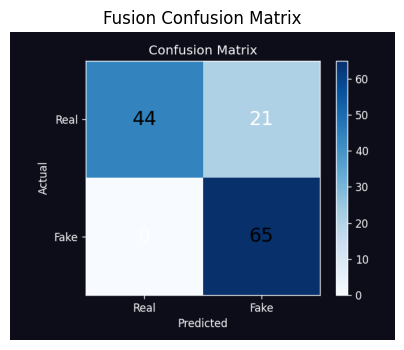

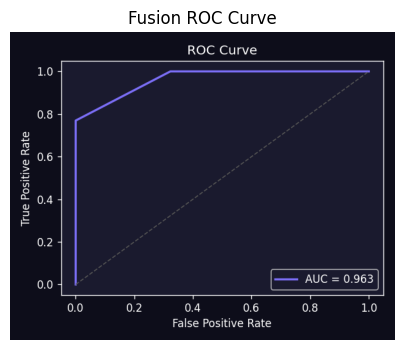

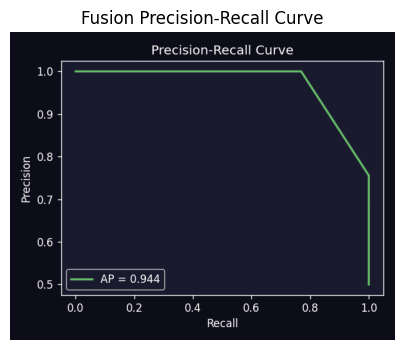

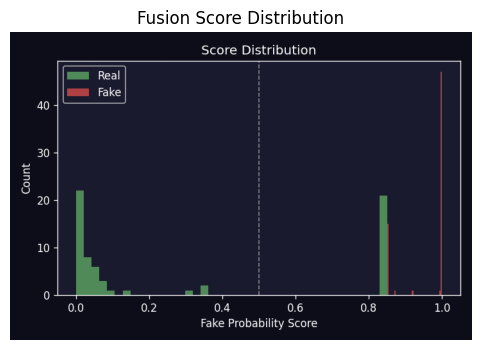

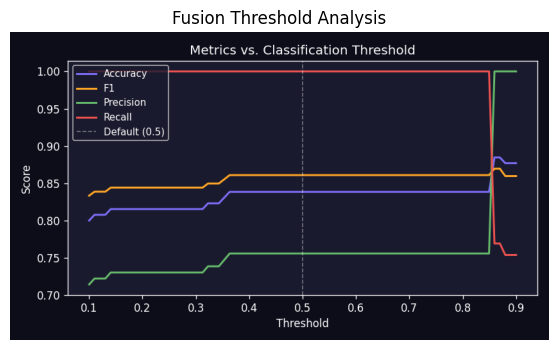

In [58]:
show_image(EVAL_DIR / 'confusion_matrix.png', 'Fusion Confusion Matrix')
show_image(EVAL_DIR / 'roc_curve.png', 'Fusion ROC Curve')
show_image(EVAL_DIR / 'pr_curve.png', 'Fusion Precision-Recall Curve')
show_image(EVAL_DIR / 'score_distribution.png', 'Fusion Score Distribution', figsize=(7, 4))
show_image(EVAL_DIR / 'threshold_analysis.png', 'Fusion Threshold Analysis', figsize=(7, 4))

## 14. Final Verdict: How a Prediction Is Formed End-to-End

A practical end-to-end prediction in this project follows this sequence:

1. **Video frames are extracted** from the input video.
2. **Face crops** are detected and scored by the video model.
3. **Audio is extracted** and converted into MFCC and mel features.
4. **Audio segments** are scored by the audio model.
5. Optional text/transcript logic may contribute additional evidence, but that is outside the requested scope here.
6. The fusion layer combines available modality probabilities.
7. Rule-based overrides adjust the score for strong evidence cases.
8. The final system outputs:
   - fake probability
   - label (`REAL` or `FAKE`)
   - confidence level
   - explanation messages
   - suspicious frames / suspicious segments where available

So the final verdict is not one single raw model output. It is the result of a **multi-stage evidence aggregation pipeline**.

In [59]:
final_verdict_table = pd.DataFrame([
    ['Video fake probability', 'Primary visual forensic evidence'],
    ['Frame-level suspiciousness', 'Helps explain which frames look manipulated'],
    ['Audio fake probability', 'Primary speech-forensic evidence'],
    ['Segment-level suspiciousness', 'Helps explain which time regions sound synthetic'],
    ['Fusion logic', 'Combines evidence into a single probability'],
    ['Decision threshold and rules', 'Convert probability into the final verdict'],
], columns=['Verdict ingredient', 'Role'])
final_verdict_table

,Verdict ingredient,Role
0,Video fake probability,Primary visual forensic evidence
1,Frame-level suspiciousness,Helps explain which frames look manipulated
2,Audio fake probability,Primary speech-forensic evidence
3,Segment-level suspiciousness,Helps explain which time regions sound synthetic
4,Fusion logic,Combines evidence into a single probability
5,Decision threshold and rules,Convert probability into the final verdict


In [60]:
def simple_weighted_demo(video_p, audio_p, video_conf=1.0, audio_conf=1.0, w_video=0.5, w_audio=0.3):
    total_w = w_video * video_conf + w_audio * audio_conf
    if total_w == 0:
        base = 0.5
    else:
        base = (w_video * video_conf * video_p + w_audio * audio_conf * audio_p) / total_w

    final_p = base
    if max(video_p, audio_p) > 0.90:
        final_p = max(final_p, 0.85)
    if video_p < 0.20 and audio_p < 0.20:
        final_p = min(final_p, 0.15)

    label = 'FAKE' if final_p >= 0.5 else 'REAL'
    return {
        'base_probability': round(base, 4),
        'final_probability': round(final_p, 4),
        'label': label,
    }

examples = pd.DataFrame([
    {'Case': 'Strong visual fake, moderate audio fake', **simple_weighted_demo(0.96, 0.62)},
    {'Case': 'Weak visual fake, strong audio fake', **simple_weighted_demo(0.41, 0.93)},
    {'Case': 'Both strongly real', **simple_weighted_demo(0.10, 0.12)},
    {'Case': 'Both borderline', **simple_weighted_demo(0.52, 0.49)},
])
examples

,Case,base_probability,final_probability,label
0,"Strong visual fake, moderate audio fake",0.8325,0.8500,FAKE
1,"Weak visual fake, strong audio fake",0.6050,0.8500,FAKE
2,Both strongly real,0.1075,0.1075,REAL
3,Both borderline,0.5088,0.5088,FAKE


## 15. Analytical Conclusions

### Main findings

- The **video branch is the strongest component** in the current project evaluation.
- The **audio branch adds complementary evidence**, especially because it has strong recall.
- The **collective verdict is recall-oriented**, which is useful for aggressive fake detection but comes with lower precision.
- The architecture is explainability-aware because it exposes **suspicious frames** and **suspicious audio segments** rather than only a single final score.

### If we describe the system in one line

This project is best described as a **multimodal forensic screening pipeline** where the visual detector is the most reliable standalone module, the audio detector provides supportive independent evidence, and the fusion layer is tuned to avoid missing fake content.

## 16. Final Verdict for the Current Analytics Story

Based on the saved evaluation artifacts in this repository:

- **Video model verdict**: best standalone model and strongest source of fake-detection evidence
- **Audio model verdict**: useful supportive detector with high recall but lower precision than video
- **Collective verdict**: safest choice when the objective is to catch as many fake samples as possible

If the project goal is **forensic screening**, the current collective design is defensible.
If the project goal is **high-confidence accusation with fewer false positives**, the fusion threshold and weighting policy should be recalibrated.

That is the most practical interpretation of the current model analytics.

In [4]:
from pathlib import Path
from models.video.video_model import VideoInference

video_model = VideoInference(Path('../data/models/video_model.pth'), 'cpu')


# Single test video
video_path = Path('D:/DOWNLOADS/fake-aabkwhhgwv.mp4')

# Run inference
prediction = video_model.predict(video_path)

# Print result
print("\n=== Video Deepfake Detection Result ===")
print(f"Video: {video_path.name}")
print(f"Prediction: {prediction}")

ModuleNotFoundError: No module named 'models'